Overlap: 0.8351495007186146


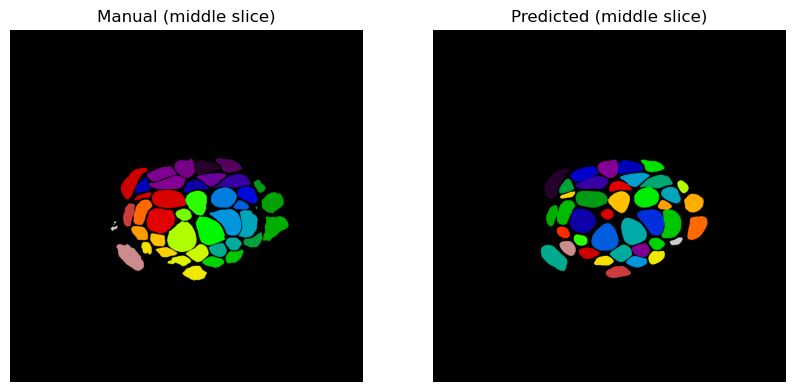

In [4]:
import matplotlib.pyplot as plt
from tifffile import imread 
import numpy as np

"""Predicition of a neuromast it was trained on, the overlap percentage is calculated!"""

manual = imread("manual_1_wt_fish1_masks.tiff")
predicted = imread("predicted_1_wt_fish1_masks.tiff")
slice_idx = manual.shape[0] // 2  # middle slice

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(manual[slice_idx], cmap="nipy_spectral")
axes[0].set_title("Manual (middle slice)")
axes[0].axis("off")

axes[1].imshow(predicted[slice_idx], cmap="nipy_spectral")
axes[1].set_title("Predicted (middle slice)")
axes[1].axis("off")

#Everything that is a non-zero is a mask
manual_bin = manual > 0
predicted_bin = predicted > 0
# where there is a a pixel in both detected
intersection = np.logical_and(manual_bin, predicted_bin)
union = np.logical_or(manual_bin, predicted_bin)
overlap = np.sum(intersection) / np.sum(union)

print("Overlap:", overlap)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io
from cellpose.io import imread
from skimage.util import invert
from skimage import io as skio
import os
import torch

io.logger_setup()

"""Uses the trained model to make a predicition. If GPU is available, gpu=True"""

# tiff files containing the neuromast nuclei and membrane channels
nuclei_path = "nucleus_1_wt_fish1.tiff"
membrane_path = "membrane_1_wt_fish1.tiff"

# path to trained model
model_path = "neuromast_cellpose_trained_model"

# output path for masks
output_path = "final_outputs"

nuclei = imread(nuclei_path)
membrane = imread(membrane_path)

# Stacking the 
img = np.zeros((2, nuclei.shape[0], nuclei.shape[1], nuclei.shape[2]), dtype=np.uint16)
img[0,:,:,:] = nuclei
img[1,:,:,:] = membrane

use_gpu = torch.backends.mps.is_available()

# Force macbook to use its GPU, does not work with cellpose's bfloat14
#model = models.CellposeModel(pretrained_model=model_path,gpu=use_gpu)

model = models.CellposeModel(pretrained_model=model_path, gpu=False) #bfloat16 error, use GPU if available
masks, flows, styles = model.eval(img, diameter=None, channels=[1,2], stitch_threshold=0.5, channel_axis=0, z_axis=1)

#save masks
save_name = os.path.join(output_path, "wtdldfish1_masks.tiff")
skio.imsave(save_name, masks, check_contrast=False)

##Show a middle slice on jupyter notebook
z = masks.shape[0] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Nuclei (input)")
plt.imshow(nuclei[z], cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Predicted Masks")
plt.imshow(masks[z], cmap='nipy_spectral')
plt.axis('off')

plt.tight_layout()
plt.show()

2026-04-06 15:26:31,102 [INFO] WRITING LOG OUTPUT TO /Users/anapineda/.cellpose/run.log
2026-04-06 15:26:31,106 [INFO] 
cellpose version: 	4.0.9 
platform:       	darwin 
python version: 	3.10.18 
torch version:  	2.2.2
2026-04-06 15:26:31,131 [INFO] reading tiff with 73 planes


100%|██████████████████████████████████████████| 73/73 [00:00<00:00, 230.92it/s]

2026-04-06 15:26:31,465 [INFO] reading tiff with 73 planes



100%|██████████████████████████████████████████| 73/73 [00:00<00:00, 539.41it/s]


2026-04-06 15:26:31,821 [INFO] >>>> using CPU
2026-04-06 15:26:31,822 [INFO] >>>> using CPU
2026-04-06 15:26:34,920 [INFO] >>>> loading model neuromast_cellpose_trained_model
2026-04-06 15:26:38,108 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-06 15:26:40,112 [INFO] 0%|          | 0/73 [00:00<?, ?it/s]
